# CRISP-DM Fraud Detection Pipeline (shop.db)

This notebook implements an end-to-end machine learning workflow to predict `orders.is_fraud` using the CRISP-DM framework and chapter-aligned techniques from data wrangling through deployment.


## 1) Business Understanding

### Problem Definition
Online orders have a non-trivial fraud rate. The business goal is to identify likely fraudulent orders early so risk teams can review or block high-risk transactions before fulfillment losses occur.

### ML Objective
Build a **binary classification pipeline** that predicts `is_fraud` for each order.

### Success Criteria
- Prioritize **high recall** on the fraud class (catch as many fraudulent orders as possible).
- Maintain practical **precision** to control manual review workload.
- Optimize and report **PR-AUC**, **ROC-AUC**, `F1`, recall, precision, confusion matrix.
- Select a probability threshold aligned to business trade-offs.

### Assumptions and Non-Goals
- Offline educational workflow in a notebook (not a production API).
- Historical labels in `orders.is_fraud` are reliable enough for supervised learning.
- We avoid target leakage by excluding identifiers and post-outcome information.


## 2) Setup and Reproducibility


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import sqlite3
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

SEED = 42
DB_PATH = Path('shop.db')
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 200)
np.random.seed(SEED)
sns.set_theme(style='whitegrid')

print('DB exists:', DB_PATH.exists())
print('Artifact directory:', ARTIFACT_DIR.resolve())



DB exists: True
Artifact directory: /Users/hannahgalindo/Desktop/Ch17 Jupyter/artifacts


## 3) Data Understanding (SQLite extraction + feature-level exploration)


In [2]:
def load_tables(db_path: Path):
    with sqlite3.connect(db_path) as conn:
        tables = {
            'orders': pd.read_sql_query('SELECT * FROM orders', conn),
            'customers': pd.read_sql_query('SELECT * FROM customers', conn),
            'order_items': pd.read_sql_query('SELECT * FROM order_items', conn),
            'products': pd.read_sql_query('SELECT * FROM products', conn),
            'shipments': pd.read_sql_query('SELECT * FROM shipments', conn),
            'product_reviews': pd.read_sql_query('SELECT * FROM product_reviews', conn),
        }
    return tables


tables = load_tables(DB_PATH)
for name, df in tables.items():
    print(f"{name:15s} shape={df.shape}")



orders          shape=(5000, 17)
customers       shape=(250, 12)
order_items     shape=(15022, 6)
products        shape=(100, 7)
shipments       shape=(5000, 9)
product_reviews shape=(3000, 6)


In [3]:
orders = tables['orders'].copy()
customers = tables['customers'].copy()
order_items = tables['order_items'].copy()
products = tables['products'].copy()
shipments = tables['shipments'].copy()

print('Orders dtypes:')
display(orders.dtypes.to_frame('dtype').T)

fraud_rate = orders['is_fraud'].mean()
print(f'Fraud rate: {fraud_rate:.4%} ({orders.is_fraud.sum()} / {len(orders)})')
orders['is_fraud'].value_counts().rename('count')



Orders dtypes:


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud
dtype,int64,int64,str,str,str,str,str,str,str,int64,str,float64,float64,float64,float64,float64,int64


Fraud rate: 6.3600% (318 / 5000)


is_fraud
0    4682
1     318
Name: count, dtype: int64

In [4]:
missing_summary = pd.DataFrame({
    'missing_pct': orders.isna().mean().sort_values(ascending=False),
    'n_unique': orders.nunique(dropna=False)
})
missing_summary.head(20)



,missing_pct,n_unique
billing_zip,0.0000,243
customer_id,0.0000,243
device_type,0.0000,3
ip_country,0.0000,6
is_fraud,0.0000,2
order_datetime,0.0000,5000
order_id,0.0000,5000
order_subtotal,0.0000,4077
order_total,0.0000,4857
payment_method,0.0000,4


In [5]:
cat_cols = ['payment_method', 'device_type', 'ip_country', 'shipping_state']
for c in cat_cols:
    if c in orders.columns:
        grp = orders.groupby(c, dropna=False)['is_fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        print(f"\nFraud rate by {c}:")
        display(grp.head(10))




Fraud rate by payment_method:


,mean,count
payment_method,,
crypto,0.103093,97
card,0.067455,3128
bank,0.059310,725
paypal,0.051429,1050



Fraud rate by device_type:


,mean,count
device_type,,
mobile,0.068032,2734
tablet,0.065934,364
desktop,0.056782,1902



Fraud rate by ip_country:


,mean,count
ip_country,,
IN,0.094737,95
GB,0.086538,104
BR,0.073171,41
CA,0.068807,218
NG,0.065217,46
US,0.062055,4496



Fraud rate by shipping_state:


,mean,count
shipping_state,,
CO,0.091657,1702
TX,0.082857,350
OR,0.075472,106
VA,0.063830,47
WA,0.060976,164
CA,0.060000,100
FL,0.057377,244
GA,0.053571,112
OH,0.048718,390


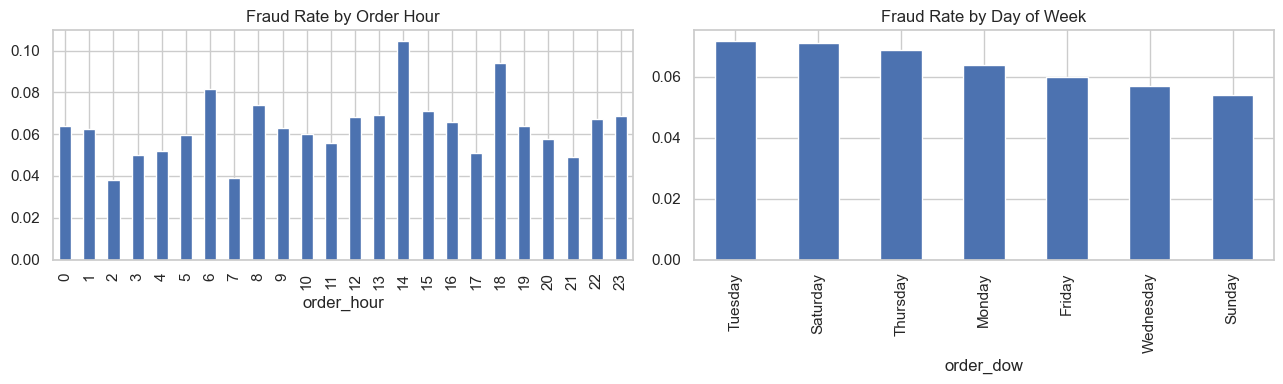

In [6]:
orders_dt = orders.copy()
orders_dt['order_datetime'] = pd.to_datetime(orders_dt['order_datetime'], errors='coerce')
orders_dt['order_hour'] = orders_dt['order_datetime'].dt.hour
orders_dt['order_dow'] = orders_dt['order_datetime'].dt.day_name()

hourly = orders_dt.groupby('order_hour', dropna=False)['is_fraud'].mean()
dow = orders_dt.groupby('order_dow', dropna=False)['is_fraud'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hourly.plot(kind='bar', ax=ax[0], title='Fraud Rate by Order Hour')
dow.plot(kind='bar', ax=ax[1], title='Fraud Rate by Day of Week')
plt.tight_layout()
plt.show()



In [7]:
num_rel = orders[['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'is_fraud']].copy()
num_rel.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)



is_fraud          1.000000
risk_score        0.270089
order_subtotal    0.206463
order_total       0.206210
tax_amount        0.195655
shipping_fee      0.014610
Name: is_fraud, dtype: float64

## 4) Data Preparation (wrangling, cleaning, feature engineering)


In [8]:
def build_order_level_dataset(orders, customers, order_items, products, shipments):
    o = orders.copy()
    c = customers.copy()
    oi = order_items.copy()
    p = products.copy()
    s = shipments.copy()

    o['order_datetime'] = pd.to_datetime(o['order_datetime'], errors='coerce')
    c['created_at'] = pd.to_datetime(c['created_at'], errors='coerce')
    c['birthdate'] = pd.to_datetime(c['birthdate'], errors='coerce')
    s['ship_datetime'] = pd.to_datetime(s['ship_datetime'], errors='coerce')

    item_agg = (
        oi.merge(p[['product_id', 'category', 'price', 'cost']], on='product_id', how='left')
          .groupby('order_id', as_index=False)
          .agg(
              item_count=('order_item_id', 'count'),
              total_quantity=('quantity', 'sum'),
              unique_products=('product_id', 'nunique'),
              unique_categories=('category', 'nunique'),
              mean_unit_price=('unit_price', 'mean'),
              sum_line_total=('line_total', 'sum'),
          )
    )

    margin_df = oi.merge(p[['product_id', 'price', 'cost']], on='product_id', how='left')
    margin_df['margin'] = margin_df['price'] - margin_df['cost']
    margin_agg = margin_df.groupby('order_id', as_index=False).agg(
        avg_item_margin=('margin', 'mean'),
        total_item_margin=('margin', 'sum')
    )

    ship_agg = s.groupby('order_id', as_index=False).agg(
        carrier=('carrier', 'first'),
        shipping_method=('shipping_method', 'first'),
        distance_band=('distance_band', 'first'),
        promised_days=('promised_days', 'mean'),
        actual_days=('actual_days', 'mean'),
        late_delivery=('late_delivery', 'max'),
        ship_datetime=('ship_datetime', 'first'),
    )

    df = (
        o.merge(c, on='customer_id', how='left', suffixes=('', '_cust'))
         .merge(item_agg, on='order_id', how='left')
         .merge(margin_agg, on='order_id', how='left')
         .merge(ship_agg, on='order_id', how='left')
    )

    df['order_hour'] = df['order_datetime'].dt.hour
    df['order_dayofweek'] = df['order_datetime'].dt.dayofweek
    df['order_month'] = df['order_datetime'].dt.month
    df['is_weekend_order'] = df['order_dayofweek'].isin([5, 6]).astype(int)

    df['customer_tenure_days'] = (df['order_datetime'] - df['created_at']).dt.days
    df['customer_age_years'] = ((df['order_datetime'] - df['birthdate']).dt.days / 365.25).round(1)

    df['zip_mismatch'] = ((df['billing_zip'].fillna('UNK') != df['shipping_zip'].fillna('UNK'))).astype(int)
    df['ip_domestic_us'] = (df['ip_country'].fillna('UNK').str.upper().eq('US')).astype(int)
    df['state_matches_customer'] = (
        df['shipping_state'].fillna('UNK').str.upper() == df['state'].fillna('UNK').str.upper()
    ).astype(int)

    df['total_to_subtotal_ratio'] = df['order_total'] / df['order_subtotal'].replace(0, np.nan)
    df['avg_item_value'] = df['sum_line_total'] / df['item_count'].replace(0, np.nan)

    df = df.sort_values(['customer_id', 'order_datetime'])
    df['prior_order_count'] = df.groupby('customer_id').cumcount()
    df['first_order_flag'] = (df['prior_order_count'] == 0).astype(int)

    drop_cols = [
        'order_id',
        'customer_id',
        'full_name',
        'email',
        'promo_code',
        'order_datetime',
        'ship_datetime',
        'created_at',
        'birthdate',
        'risk_score',
    ]
    drop_cols = [c for c in drop_cols if c in df.columns]

    y = df['is_fraud'].astype(int).copy()
    X = df.drop(columns=drop_cols + ['is_fraud']).copy()
    X = X.replace([np.inf, -np.inf], np.nan)

    # Safety check in case risk_score appears from upstream changes.
    if 'risk_score' in X.columns:
        X = X.drop(columns=['risk_score'])

    return X, y, df


X, y, modeling_df = build_order_level_dataset(orders, customers, order_items, products, shipments)
print('Modeling X shape:', X.shape)
print('Target positive rate:', y.mean().round(4))
X.head()



Modeling X shape: (5000, 45)
Target positive rate: 0.0636


,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,order_subtotal,shipping_fee,tax_amount,order_total,gender,city,state,zip_code,customer_segment,loyalty_tier,is_active,item_count,total_quantity,unique_products,unique_categories,mean_unit_price,sum_line_total,avg_item_margin,total_item_margin,carrier,shipping_method,distance_band,promised_days,actual_days,late_delivery,order_hour,order_dayofweek,order_month,is_weekend_order,customer_tenure_days,customer_age_years,zip_mismatch,ip_domestic_us,state_matches_customer,total_to_subtotal_ratio,avg_item_value,prior_order_count,first_order_flag
592,28289,28289,CO,crypto,mobile,US,0,470.47,8.04,36.06,514.57,Female,Clayton,CO,28289,standard,silver,1,4,5,4,4,106.340000,470.47,41.555000,166.22,USPS,standard,regional,6.0,7.0,1,22,2,7,0,-94,20.1,0,1,1,1.093736,117.6175,0,1
912,28289,28289,CO,paypal,mobile,US,0,518.15,8.04,47.95,574.14,Female,Clayton,CO,28289,standard,silver,1,4,5,4,3,93.777500,518.15,37.905000,151.62,UPS,standard,local,5.0,5.0,0,23,2,7,0,-94,20.1,0,1,1,1.108058,129.5375,1,0
902,28289,28289,CO,paypal,mobile,US,0,152.62,24.99,9.40,187.01,Female,Clayton,CO,28289,standard,silver,1,2,2,2,2,76.310000,152.62,26.890000,53.78,UPS,overnight,national,3.0,2.0,0,2,3,7,0,-94,20.1,0,1,1,1.225331,76.3100,2,0
343,28289,28289,CO,card,desktop,US,0,205.29,8.04,16.69,230.02,Female,Clayton,CO,28289,standard,silver,1,3,5,3,2,42.383333,205.29,16.683333,50.05,UPS,standard,regional,6.0,7.0,1,8,3,7,0,-94,20.1,0,1,1,1.120464,68.4300,3,0
737,28289,28289,CO,bank,mobile,US,0,64.53,12.99,4.44,81.96,Female,Clayton,CO,28289,standard,silver,1,1,1,1,1,64.530000,64.53,22.380000,22.38,UPS,expedited,local,2.0,3.0,1,9,3,7,0,-94,20.1,0,1,1,1.270107,64.5300,4,0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print('Fraud rates -> train:', round(y_train.mean(), 4), 'test:', round(y_test.mean(), 4))



Train shape: (4000, 45)
Test shape : (1000, 45)
Fraud rates -> train: 0.0635 test: 0.064


## 5) Automated Preparation Pipeline (Chapter 7 style)


In [10]:
num_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols),
        ('cat', categorical_pipe, cat_cols),
    ],
    remainder='drop'
)

print('Numeric columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))



Numeric columns: 30
Categorical columns: 15


## 6) Modeling (baseline + ensemble models)


In [11]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=1
    ),
    'GradientBoosting': GradientBoostingClassifier(random_state=SEED),
}

scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('clf', model)])
    scores = cross_validate(pipe, X_train, y_train, scoring=scoring, cv=cv, n_jobs=1)
    row = {'model': name}
    for metric in scoring:
        row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'{metric}_std'] = scores[f'test_{metric}'].std()
    cv_results.append(row)

cv_df = pd.DataFrame(cv_results).sort_values('pr_auc_mean', ascending=False)
cv_df



,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std
0,LogisticRegression,0.976981,0.009500,0.825466,0.047938,0.869961,0.052371,0.541948,0.052148,0.667106,0.052114
2,GradientBoosting,0.970297,0.010562,0.806950,0.061421,0.562902,0.102901,0.869138,0.055187,0.677452,0.080290
1,RandomForest,0.895024,0.030761,0.443613,0.068150,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 7) Evaluation, Selection, and Tuning (Chapter 15)


In [12]:
best_model_name = cv_df.iloc[0]['model']
print('Best CV model by PR-AUC:', best_model_name)

if best_model_name == 'RandomForest':
    base_clf = RandomForestClassifier(class_weight='balanced_subsample', random_state=SEED, n_jobs=1)
    param_grid = {
        'clf__n_estimators': [200, 400],
        'clf__max_depth': [None, 8, 14],
        'clf__min_samples_leaf': [1, 3, 5],
        'clf__max_features': ['sqrt', 0.5],
    }
elif best_model_name == 'GradientBoosting':
    base_clf = GradientBoostingClassifier(random_state=SEED)
    param_grid = {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.03, 0.05, 0.1],
        'clf__max_depth': [2, 3],
        'clf__subsample': [0.8, 1.0],
    }
else:
    base_clf = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED)
    param_grid = {
        'clf__C': [0.1, 0.5, 1.0, 2.0],
        'clf__solver': ['lbfgs'],
    }

tuning_pipe = Pipeline(steps=[('prep', preprocessor), ('clf', base_clf)])

search = GridSearchCV(
    estimator=tuning_pipe,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=1,
    verbose=0,
    refit=True,
)
search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print('Best CV PR-AUC:', round(search.best_score_, 4))
best_pipeline = search.best_estimator_



Best CV model by PR-AUC: LogisticRegression
Best params: {'clf__C': 0.1, 'clf__solver': 'lbfgs'}
Best CV PR-AUC: 0.849


In [13]:
train_proba = best_pipeline.predict_proba(X_train)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, train_proba)

f1_vals = 2 * (precision[:-1] * recall[:-1]) / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
valid_idx = np.where(recall[:-1] >= 0.70)[0]
if len(valid_idx) > 0:
    idx = valid_idx[np.argmax(f1_vals[valid_idx])]
else:
    idx = int(np.argmax(f1_vals))

selected_threshold = float(thresholds[idx])
print('Selected threshold:', round(selected_threshold, 4))
print('Precision at threshold:', round(float(precision[idx]), 4))
print('Recall at threshold   :', round(float(recall[idx]), 4))
print('F1 at threshold       :', round(float(f1_vals[idx]), 4))



Selected threshold: 0.8094
Precision at threshold: 0.8482
Recall at threshold   : 0.8583
F1 at threshold       : 0.8532


In [14]:
test_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= selected_threshold).astype(int)

metrics = {
    'roc_auc': roc_auc_score(y_test, test_proba),
    'pr_auc': average_precision_score(y_test, test_proba),
    'precision': precision_score(y_test, test_pred, zero_division=0),
    'recall': recall_score(y_test, test_pred, zero_division=0),
    'f1': f1_score(y_test, test_pred, zero_division=0),
}

print('Test metrics:')
for k, v in metrics.items():
    print(f'  {k:10s}: {v:.4f}')

print('\nConfusion matrix (thresholded):')
print(confusion_matrix(y_test, test_pred))

print('\nClassification report:')
print(classification_report(y_test, test_pred, digits=4, zero_division=0))



Test metrics:
  roc_auc   : 0.9797
  pr_auc    : 0.8435
  precision : 0.8333
  recall    : 0.7031
  f1        : 0.7627

Confusion matrix (thresholded):
[[927   9]
 [ 19  45]]

Classification report:
              precision    recall  f1-score   support

           0     0.9799    0.9904    0.9851       936
           1     0.8333    0.7031    0.7627        64

    accuracy                         0.9720      1000
   macro avg     0.9066    0.8468    0.8739      1000
weighted avg     0.9705    0.9720    0.9709      1000



## 8) Feature Selection (Chapter 16)


In [15]:
numeric_train = X_train[num_cols].copy()
num_imputed = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(numeric_train),
    columns=numeric_train.columns,
    index=numeric_train.index,
)

vt = VarianceThreshold(threshold=0.0)
vt.fit(num_imputed)
kept_num_cols = numeric_train.columns[vt.get_support()].tolist()
removed_num_cols = [c for c in numeric_train.columns if c not in kept_num_cols]

print('Numeric features kept after VarianceThreshold:', len(kept_num_cols))
print('Removed constant numeric features:', removed_num_cols)



Numeric features kept after VarianceThreshold: 29
Removed constant numeric features: ['is_active']


In [16]:
prep_only = clone(preprocessor)
X_train_prepared = prep_only.fit_transform(X_train)
X_test_prepared = prep_only.transform(X_test)

try:
    transformed_feature_names = prep_only.get_feature_names_out().tolist()
except Exception:
    transformed_feature_names = [f'f_{i}' for i in range(X_train_prepared.shape[1])]

selector_est = LogisticRegression(
    penalty='l1',
    C=0.2,
    solver='liblinear',
    class_weight='balanced',
    max_iter=3000,
    random_state=SEED,
)
selector = SelectFromModel(selector_est)
selector.fit(X_train_prepared, y_train)

selected_mask = selector.get_support()
selected_features = [f for f, keep in zip(transformed_feature_names, selected_mask) if keep]

print('Selected transformed features:', len(selected_features), '/', len(transformed_feature_names))
print('Top selected feature examples:', selected_features[:20])



Selected transformed features: 38 / 1145
Top selected feature examples: ['num__promo_used', 'num__shipping_fee', 'num__tax_amount', 'num__total_quantity', 'num__unique_categories', 'num__avg_item_margin', 'num__total_item_margin', 'num__promised_days', 'num__actual_days', 'num__late_delivery', 'num__order_hour', 'num__order_dayofweek', 'num__order_month', 'num__is_weekend_order', 'num__customer_tenure_days', 'num__zip_mismatch', 'num__state_matches_customer', 'num__avg_item_value', 'num__prior_order_count', 'cat__billing_zip_76784']


In [17]:
full_logit_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED))
])
full_logit_pipe.fit(X_train, y_train)

full_test_proba = full_logit_pipe.predict_proba(X_test)[:, 1]
full_pr_auc = average_precision_score(y_test, full_test_proba)

X_train_sel = selector.transform(X_train_prepared)
X_test_sel = selector.transform(X_test_prepared)
sel_logit = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED)
sel_logit.fit(X_train_sel, y_train)
sel_test_proba = sel_logit.predict_proba(X_test_sel)[:, 1]
sel_pr_auc = average_precision_score(y_test, sel_test_proba)

print(f'Full-feature logistic PR-AUC: {full_pr_auc:.4f}')
print(f'Selected-feature logistic PR-AUC: {sel_pr_auc:.4f}')



Full-feature logistic PR-AUC: 0.8291
Selected-feature logistic PR-AUC: 0.8627


In [18]:
perm = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring='average_precision',
    n_repeats=8,
    random_state=SEED,
    n_jobs=1,
)

# For a pipeline estimator, permutation importance is returned per original input column.
feat_names = X_test.columns.to_numpy()

imp_df = pd.DataFrame({
    'feature': feat_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

imp_df.head(20)



,feature,importance_mean,importance_std
30,actual_days,0.734162,0.014623
29,promised_days,0.473017,0.044753
34,order_month,0.076652,0.018172
36,customer_tenure_days,0.066544,0.015166
27,shipping_method,0.065057,0.014420
42,avg_item_value,0.049801,0.016924
19,total_quantity,0.043732,0.015388
31,late_delivery,0.042497,0.013127
25,total_item_margin,0.037751,0.010366
38,zip_mismatch,0.018892,0.007763


## 9) Deployment (Chapter 17): Serialize and Integrate


In [19]:
final_pipeline = clone(best_pipeline)
final_pipeline.fit(X_train, y_train)

pipeline_path = ARTIFACT_DIR / 'fraud_pipeline.joblib'
joblib.dump(final_pipeline, pipeline_path)

metadata = {
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'db_path': str(DB_PATH),
    'target': 'is_fraud',
    'train_rows': int(X_train.shape[0]),
    'test_rows': int(X_test.shape[0]),
    'selected_threshold': selected_threshold,
    'best_model_family': best_model_name,
    'best_params': search.best_params_,
    'test_metrics': {k: float(v) for k, v in metrics.items()},
    'raw_feature_columns': X.columns.tolist(),
}

metadata_path = ARTIFACT_DIR / 'fraud_pipeline_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved pipeline:', pipeline_path)
print('Saved metadata:', metadata_path)



Saved pipeline: artifacts/fraud_pipeline.joblib
Saved metadata: artifacts/fraud_pipeline_metadata.json


In [20]:
loaded_pipeline = joblib.load(ARTIFACT_DIR / 'fraud_pipeline.joblib')

X_latest, y_latest, _ = build_order_level_dataset(orders, customers, order_items, products, shipments)
sample_rows = X_latest.sample(5, random_state=SEED)

sample_proba = loaded_pipeline.predict_proba(sample_rows)[:, 1]
sample_pred = (sample_proba >= selected_threshold).astype(int)

inference_demo = sample_rows.copy()
inference_demo['pred_fraud_proba'] = sample_proba
inference_demo['pred_is_fraud'] = sample_pred
inference_demo[['pred_fraud_proba', 'pred_is_fraud']].head()



,pred_fraud_proba,pred_is_fraud
1503,0.009517,0
2544,0.001921,0
2557,0.166913,0
10,0.000437,0
189,0.000151,0


## 10) Conclusion and Next Steps

- Built a complete CRISP-DM fraud pipeline from SQLite extraction through serialized deployment artifacts.
- Compared baseline and ensemble models using stratified cross-validation and imbalance-aware metrics.
- Tuned model hyperparameters and selected a business-aligned threshold emphasizing fraud recall.
- Evaluated feature-selection approaches and model importances for transparency.
- Saved reusable artifacts for integration (`artifacts/fraud_pipeline.joblib`, metadata JSON).

### Recommended production next steps
1. Add scheduled retraining and drift checks (label prevalence, feature distribution shifts).
2. Log predictions/decisions for post-deployment monitoring and recalibration.
3. Revisit threshold policy with real investigation capacity and fraud-loss cost estimates.
4. Add fairness and regional bias diagnostics before policy deployment.
